# Markov Chain Monte Carlo

We will start our discussion of MCMC. The simplest MCMC method is the Metropolis Algorithm. 

In [164]:
import numpy as np
import matplotlib.pyplot as plt

## Example One

The goal is to use the Metropolis Algorithm to approximate the following density. 

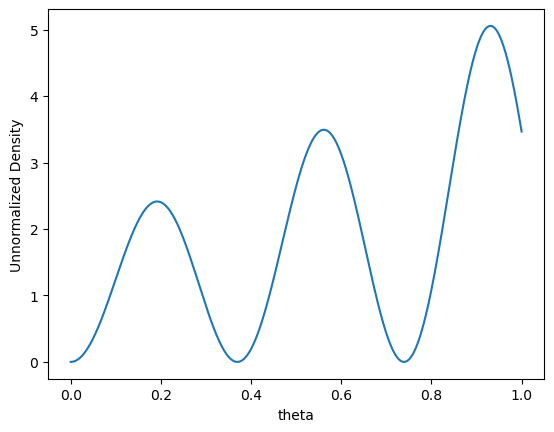

In [198]:
def f(th): 
    return (np.sin(8.5 * th) ** 2) * (th >= 0) * (th <= 1) * 2*np.exp(th)

th = np.arange(0, 1.001, 0.001)
plt.plot(th, f(th))
plt.xlabel("theta")
plt.ylabel("Unnormalized Density")
plt.show()

The above function is not a quite a density because it does not integrate to one. Its integral is given by:

In [199]:
from scipy.integrate import quad
val, err = quad(f, 0, 1)
print(val)

1.8775056565536072


Below is the Random-Walk Metropolis algorithm for obtaining samples approximating this density. One gets a different version of the algorithm for different methods of selecting the candidate. 

Rejection rate: 0.8909575


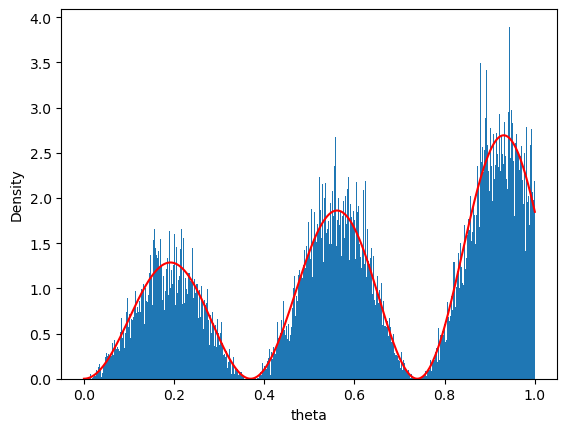

In [202]:
nit = 400000
path = np.empty(nit)
state = 0.4 #initialization
path[0] = state
rej = 0

for i in range(1, nit):
    #candidate = np.random.uniform(state - 0.4, state + 0.4)
    #candidate = np.random.normal(loc = state, scale = 0.08)
    candidate = np.random.normal(loc = state, scale = 2)
    #candidate = np.random.uniform(0, 1) #note here candidate does not depend on the current state
    ratio = f(candidate) / f(state)
    rnum = np.random.uniform(0, 1)
    if rnum >= ratio: 
        rej += 1
    else:
        state = candidate
    path[i] = state

print("Rejection rate:", rej / nit)

plt.hist(path, bins = 1000, density = True)
plt.xlabel("theta")
plt.ylabel("Density")
plt.plot(th, f(th)/val, color = "red")
plt.show()

Below is the 'trace plot' (i.e., plot of $\theta^{(t)}$) for the last 2000 iterations. 

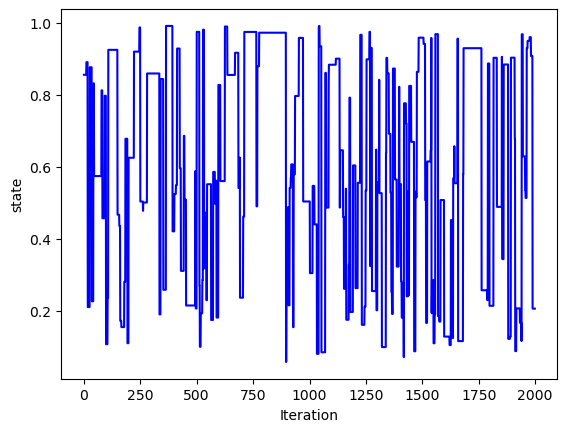

In [203]:
#Here are the last 2000 iterations of the path: 
plt.plot(path[nit - 2000:], color = "blue")
plt.xlabel("Iteration")
plt.ylabel("state")
plt.show()

## Example Two: Metropolis for Bayesian Beta-Binomial inference

Consider the simple Beta-Binomial example. Prior is Beta(a, b) and Likelihood is $X \sim Bin(n, \theta)$. We have seen previously that tthe posterior is given by $Bin(X + a, n-X + b)$.

Here are the functions for the likelihood, prior and (unnormalized) posterior. 

In [204]:
from scipy.special import gammaln #this is to calculate the Binomial coefficients

a = 12
b = 120000
x = 100
n = 500000

def lik(th):
    if th < 0 or th > 1:
        return 0.0
    return np.exp(gammaln(n + 1) - gammaln(x + 1) - gammaln(n - x + 1) + x * np.log(th) + (n - x) * np.log(1 - th))

def prior(th):
    if th < 0 or th > 1:
        return 0.0
    return np.exp((a - 1) * np.log(th) + (b - 1) * np.log(1 - th))

def posterior(th):
    return lik(th) * prior(th)

from scipy.integrate import quad
val, err = quad(posterior, 0, 20*(x/n))
print(val, err)

5.907639805069782e-58 1.0821820585301677e-57


Rejection rate: 0.1828175


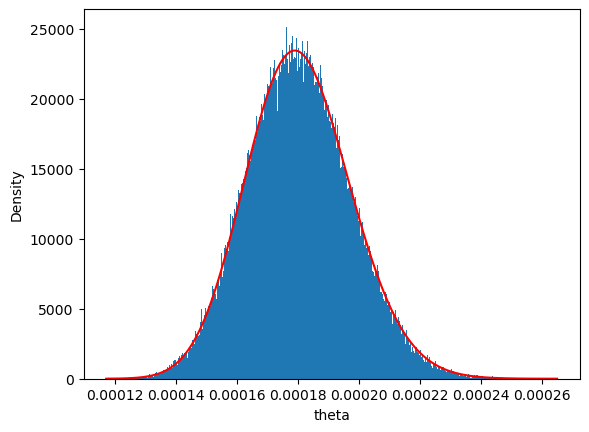

In [205]:
nit = 400000
path = np.empty(nit)
state = x/n #initialization
path[0] = state
rej = 0

for i in range(1, nit):
    candidate = np.random.normal(loc = state, scale = 1e-5) #scale 1e-5 works
    #candidate = np.random.normal(loc = state, scale = 1e-2) #does not work (poor mixing)
    ratio = posterior(candidate) / posterior(state)
    rnum = np.random.uniform(0, 1)
    if rnum >= ratio: 
        rej += 1
    else:
        state = candidate
    path[i] = state

print("Rejection rate:", rej / nit)

plt.hist(path, bins = 1000, density = True)
plt.xlabel("theta")
plt.ylabel("Density")
#plotting the Beta(a + x, b + n - x) density for comparison
from scipy.stats import beta
th = np.sort(path)
plt.plot(th, beta.pdf(th, a + x, b + n - x), color = "red") 
plt.show()

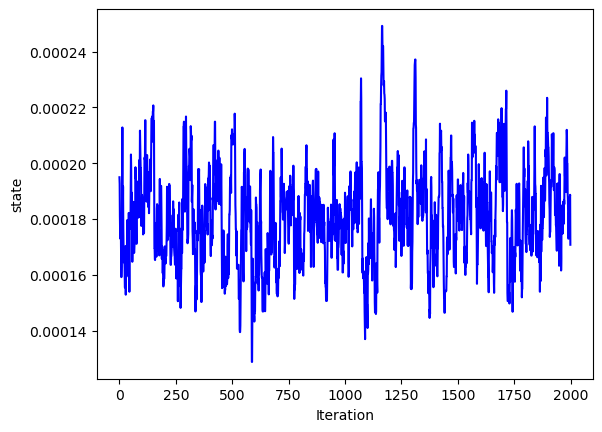

In [206]:
#Here are the last 2000 iterations of the path: 
plt.plot(path[nit - 2000:], color = "blue")
plt.xlabel("Iteration")
plt.ylabel("state")
plt.show()

When the scale of the proposal distribution is changed to $1e-2$ from $1e-5$, the algorithm has very poor mixing. 

## Example Three: Binomial inference with non-conjugate prior

Now consider the problem of estimating $\theta$ from $X \sim Bin(n, \theta)$ with the prior $\log (\theta/(1 - \theta)) \sim N(\mu, \sigma^2)$. The prior density for $\theta$ is given by: 
\begin{align*}
   f_{\theta}(\theta) = \frac{1}{\sqrt{2 \pi} \sigma} \frac{1}{\theta(1 - \theta)} \exp \left(-\frac{1}{2} \left(\log \frac{\theta}{1 - \theta} - \mu \right)^2 \right)
\end{align*}

Here is the code for the prior and posterior. 

In [207]:
#Now we will use the prior log(\theta/1-\theta) \sim N(mu, sig^2) instead of the Beta(a, b) prior.
mu = -9
sig = 0.3
print(mu, sig) #these values are chosen to make the prior density look similar to the Beta(12, 120000) prior density

def prior(th):
    if th < 0 or th > 1:
        return 0.0
    z = np.log(th / (1 - th))
    return np.exp(-0.5 * ((z - mu) / sig)**2) / (sig * np.sqrt(2 * np.pi) * th * (1 - th))

def posterior(th):
    return prior(th) * lik(th)

-9 0.3


Below is the Metropolis code. 

Rejection rate: 0.1685225


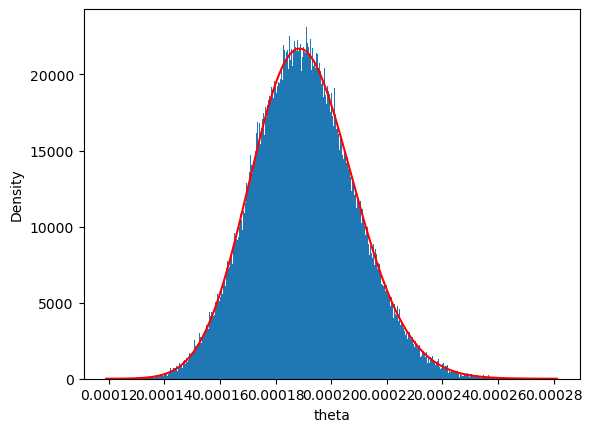

In [210]:
nit = 400000
path = np.empty(nit)
state = x/n #initialization
path[0] = state
rej = 0

for i in range(1, nit):
    candidate = np.random.normal(loc = state, scale = 1e-5) #scale 1e-5 works
    #candidate = np.random.normal(loc = state, scale = 1e-2) #does not work (poor mixing)
    ratio = posterior(candidate) / posterior(state)
    rnum = np.random.uniform(0, 1)
    if rnum >= ratio: 
        rej += 1
    else:
        state = candidate
    path[i] = state

print("Rejection rate:", rej / nit)

plt.hist(path, bins = 1000, density = True)
plt.xlabel("theta")
plt.ylabel("Density")
#plotting the Beta(a + x, b + n - x) density for comparison
th = np.sort(path)
post_unnorm = np.array([posterior(t) for t in th])
plt.plot(th, post_unnorm / np.trapezoid(post_unnorm, th), color="red")
plt.show()

Again the mixing is good when the scale of the Gaussian proposal distribution is $1e-5$, and poor when it is $1e-2$. 

## Example Four: Normal Likelihood and prior

The following is a simple example with prior given by $\theta \sim N(\mu_), \sigma_0^2)$ and likelihood given by $N(\theta, \sigma^2)$. We are considering posterior inference with $X = 130$ (observation), $\sigma = 5$, $\mu_0 = 120$ and $\sigma_0 = 10$. 

In [211]:
X, sig = 130, 5
mu_prior, sig_prior = 120, 10

def dnorm(x, mu, s):
    return np.exp(-0.5 * ((x - mu) / s)**2) / (s * np.sqrt(2 * np.pi))

def lik(th):
    return dnorm(X, th, sig)

def prior(th):
    return dnorm(th, mu_prior, sig_prior)

def post(th):
    return prior(th) * lik(th)

The Metropolis algorithm is coded below. 

In [ ]:
nit = 400000
path = np.empty(nit)
state = 130.0
path[0] = state
rej = 0

for it in range(1, nit):
    cand = np.random.normal(loc = state, scale = 3)
    ratio = post(cand) / post(state)
    u = np.random.uniform()
    if u < ratio:
        state = cand
    else:
        rej += 1
    path[it] = state

print(rej / nit)

plt.hist(path, bins=1000, density=True)
#True posterior:
mu_post = ((X / sig**2) + (mu_prior / sig_prior**2)) / ((1 / sig**2) + (1 / sig_prior**2))
sig_post = np.sqrt(1 / ((1 / sig**2) + (1 / sig_prior**2)))
th = np.arange(path.min(), path.max(), 0.01)
plt.plot(th, dnorm(th, mu_post, sig_post), color="red")
plt.show()

## Example Five: Linear Regression

This is our first multidimensional example. The problem is simple linear regression so there are three parameters: $\beta_0, \beta_1, \sigma$. 

In [212]:
import pandas as pd
height = pd.read_csv("PearsonHeightData.txt", sep = r"\s+")
print(height)

      Father   Son
0       65.0  59.8
1       63.3  63.2
2       65.0  63.3
3       65.8  62.8
4       61.1  64.3
...      ...   ...
1073    67.0  70.8
1074    71.3  68.3
1075    71.8  69.3
1076    70.7  69.3
1077    70.3  67.0

[1078 rows x 2 columns]


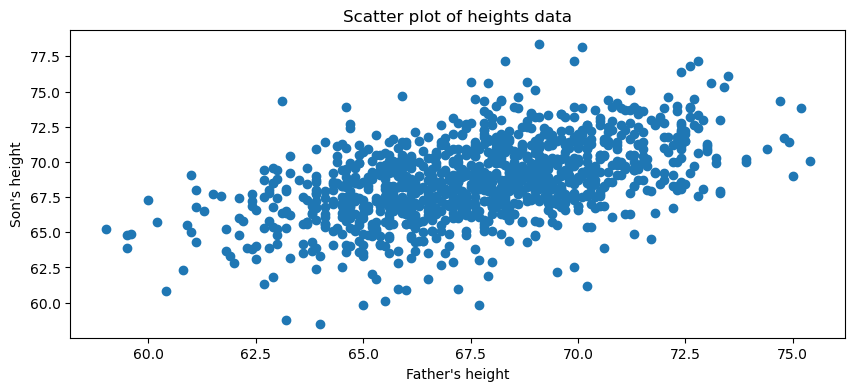

In [213]:
plt.figure(figsize = (10, 4))
plt.scatter(height["Father"], height["Son"])
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

In [214]:
n = height.shape[0]
X = np.column_stack([np.ones(n), height["Father"]]) #this is the X matrix (consisting of covariates and the column of ones)
y = height["Son"] #this is the y vector consisting of response values


For comparison, here is the least squares fit. 

In [185]:
import statsmodels.api as sm
linmod = sm.OLS(y, X).fit()
print(linmod.summary())


                            OLS Regression Results                            
Dep. Variable:                    Son   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     360.9
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.27e-69
Time:                        13:56:31   Log-Likelihood:                -2489.4
No. Observations:                1078   AIC:                             4983.
Df Residuals:                    1076   BIC:                             4993.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8928      1.833     18.491      0.0

The estimate of $\sigma$ is obtained as follows. 

In [215]:
bhat = linmod.params.values
print(bhat)
Sbhat = np.sum(linmod.resid ** 2)
m = X.shape[1] - 1 #in this case, m = 1
sighat = np.sqrt(Sbhat/(n-m-1)) #this is also called the residual standard error
print(sighat)

[33.89280054  0.51400591]
2.438134379352427


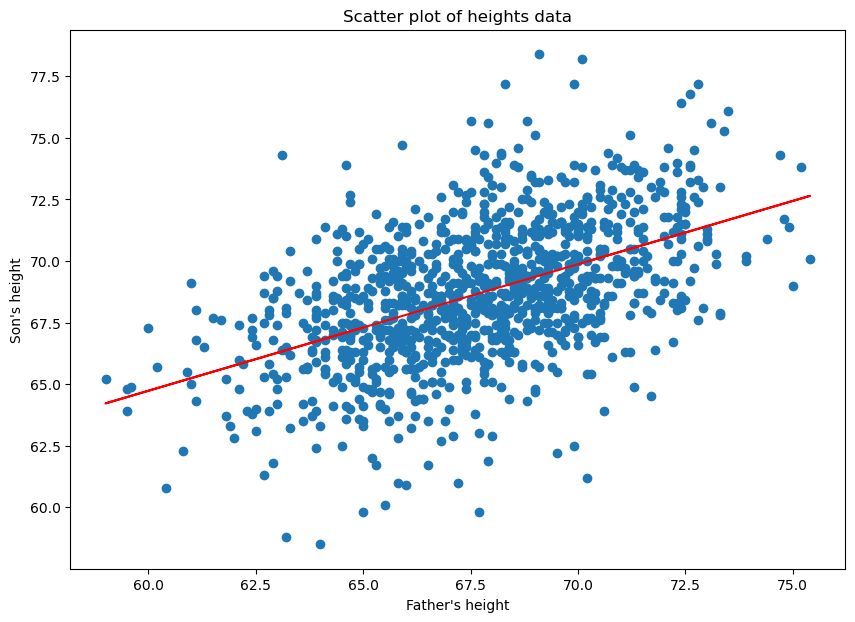

In [187]:
plt.figure(figsize = (10, 7))
plt.scatter(height["Father"], height["Son"])
x = height["Father"].values
plt.plot(x, linmod.fittedvalues, 'r')
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

We now define the likelihood, prior and posterior for Bayesian inference with the Metropolis algorithm. We shall parametrize the problem in terms of $\beta_0, \beta_1$ and $\log \sigma$ (instead of $\sigma$). 

In [220]:
n = len(y)
x = height["Father"].to_numpy()
y = height["Son"].to_numpy()

def loglik(th):
    beta0, beta1, logsigma = th
    sigma = np.exp(logsigma)
    return -n * np.log(sigma) - np.sum((y - beta0 - beta1 * x) ** 2) / (2 * sigma**2)

In [221]:
def logprior(th):
    beta0, beta1, logsigma = th
    if -200 <= beta0 <= 200 and -200 <= beta1 <= 200 and -200 <= logsigma <= 200:
        return np.log((1/400) * (1/400) * (1/400))
    return -np.inf

In [222]:
#Unnormalized Posterior
def logpost(th):
    return loglik(th) + logprior(th)

We are now working with log-prior, log-likelihood and log-posterior instead of posterior. This makes the computations stable.

The challenge now is in the proposal distribution. We will take it to be given by independent normals. The scales of the normals need to be chosen carefully though. Note that here that the variables here $\beta_0, \beta_1, \log \sigma$ are on different scales (as can be seen from the estimates and standard errors in the linear regression summary). 

In [223]:
nit = 400000
path = np.zeros((nit, 3))
state = np.array([0.0, 0.0, 0.0])
path[0] = state
rej = 0

for it in range(1, nit):
    cand = state + np.array([np.random.normal(scale=0.1),np.random.normal(scale=0.001),np.random.normal(scale=0.01)]) #this works well
    #cand = state + np.array([np.random.normal(scale=0.1),np.random.normal(scale=0.1),np.random.normal(scale=0.1)]) #this does not work
    logratio = logpost(cand) - logpost(state)
    if np.log(np.random.uniform()) < logratio:
        state = cand
    else:
        rej += 1
    path[it] = state

print(rej / nit)

0.47582


In [224]:
beta0, beta1, logsigma = path[100000:, 0], path[100000:, 1], path[100000:, 2] #we are discarding the first 100000 iterations as burn-in

print(np.mean(beta0), np.std(beta0))
print(np.mean(beta1), np.std(beta1))
print(np.mean(logsigma), np.std(logsigma))
print(np.exp(np.mean(logsigma)), np.exp(np.std(logsigma)))

print(linmod.summary())
print(sighat)

33.604022436453214 1.9236727765562034
0.5182672403018774 0.028400803552315227
0.8916462091055167 0.021533275635037
2.439141685312359 1.0217667897104907
                            OLS Regression Results                            
Dep. Variable:                    Son   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     360.9
Date:                Mon, 30 Mar 2026   Prob (F-statistic):           1.27e-69
Time:                        15:04:03   Log-Likelihood:                -2489.4
No. Observations:                1078   AIC:                             4983.
Df Residuals:                    1076   BIC:                             4993.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|    

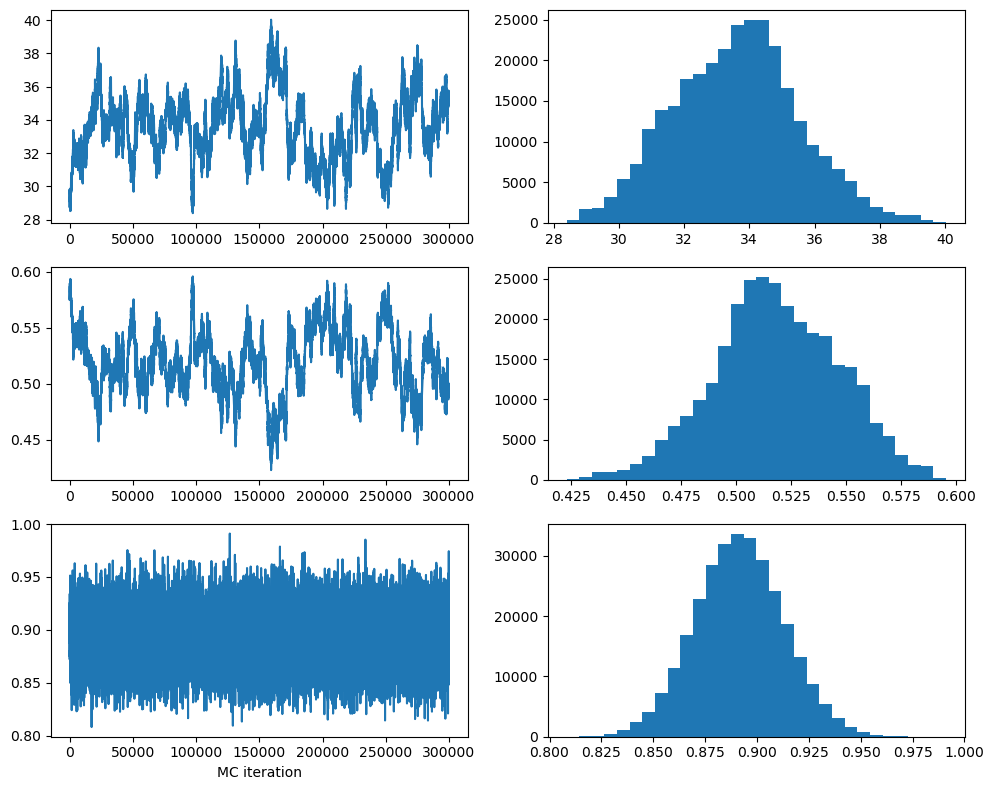

33.604022436453214 0.5182672403018774 0.8916462091055167


In [225]:
plt.figure(figsize=(10, 8))
plt.subplot(3, 2, 1); plt.plot(beta0)
plt.subplot(3, 2, 2); plt.hist(beta0, bins=30)
plt.subplot(3, 2, 3); plt.plot(beta1)
plt.subplot(3, 2, 4); plt.hist(beta1, bins=30)
plt.subplot(3, 2, 5); plt.plot(logsigma); plt.xlabel("MC iteration")
plt.subplot(3, 2, 6); plt.hist(logsigma, bins=30)
plt.tight_layout()
plt.show()

print(np.mean(beta0), np.mean(beta1), np.mean(logsigma))